In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import pandas as pd

!pip3 install h5flow
import h5flow
from h5flow.data import dereference

In [ ]:
int_to_height = 8.33
bin_size_cm = 1
threshold_acl = 6 / int_to_height
threshold_lcm = 20 / int_to_height

#filename = '~/dune/light_file_processing/outputs/mr6-5_no_th/truth_reco_match_n1000.csv'
#filename = '~/dune/light_file_processing/gnn_outputs/inputs_1000_files.csv'
filename = '/pscratch/sd/j/jvmead/to_dataframes/truth_reco_match_n1000_opt.csv'
df_truth_reco = pd.read_csv(filename)

# bins
xbins = np.arange(-70, 70 + bin_size_cm, bin_size_cm)
ybins = np.arange(-70, 70 + bin_size_cm, bin_size_cm)
zbins = np.arange(-70, 70 + bin_size_cm, bin_size_cm)

In [3]:
bit16 = 2**16 - 1
# use integer division so the 'num' argument to linspace is an int
wvfm_samples = np.linspace(-bit16//2, bit16//2, bit16)
# print first and last samples
print(wvfm_samples[0], wvfm_samples[-1])

wvfm_test1 = (wvfm_samples - wvfm_samples % 4).astype(float)
print(wvfm_test1[0], wvfm_test1[-1])

# interpret samples as signed 16-bit ints, then right-shift and convert back to float
wvfm_test2 = (wvfm_samples.astype(np.int16) >> 2).astype(float)
print(wvfm_test2[0], wvfm_test2[-1])

-32768.0 32767.0
-32768.0 32764.0
-8192.0 8191.0


In [4]:
tpc_bounds_cm = []
with h5py.File('/global/cfs/cdirs/dune/www/data/2x2/simulation/productions/MiniRun6.5_1E19_RHC/MiniRun6.5_1E19_RHC.flow/FLOW/0000000/MiniRun6.5_1E19_RHC.flow.0000000.FLOW.hdf5', 'r') as f:
    n_events = f['light/wvfm/data']['samples'].shape[0]
    mod_bounds_cm = np.array(f['geometry_info'].attrs['module_RO_bounds'])
    max_drift_distance = f['geometry_info'].attrs['max_drift_distance']
    for mod in mod_bounds_cm:
        x_min, x_max = mod[0][0], mod[1][0]
        y_min, y_max = mod[0][1], mod[1][1]
        z_min, z_max = mod[0][2], mod[1][2]
        x_min_adj = x_max - max_drift_distance
        x_max_adj = x_min + max_drift_distance
        tpc_bounds_cm.append(((x_min_adj, y_min, z_min), (x_max, y_max, z_max)))
        tpc_bounds_cm.append(((x_min, y_min, z_min), (x_max_adj, y_max, z_max)))
    tpc_bounds_cm = np.array(tpc_bounds_cm)
del f

# x-bounds: get unique first elements of each bound
tpc_bounds_rounded = tpc_bounds_cm #np.round(tpc_bounds_cm).astype(int)
x_bounds = [tuple(b) for b in tpc_bounds_rounded[:, :, 0]]
y_bounds = [tuple(b) for b in tpc_bounds_rounded[:, :, 1]]
z_bounds = [tuple(b) for b in tpc_bounds_rounded[:, :, 2]]

for i, xb in enumerate(x_bounds):
    print(f'TPC {i} X bounds (cm): {xb}')
for i, yb in enumerate(y_bounds):
    print(f'TPC {i} Y bounds (cm): {yb}')
for i, zb in enumerate(z_bounds):
    print(f'TPC {i} Z bounds (cm): {zb}')


TPC 0 X bounds (cm): (np.float64(33.65875219726563), np.float64(64.08975219726562))
TPC 1 X bounds (cm): (np.float64(2.910249948501587), np.float64(33.341249948501584))
TPC 2 X bounds (cm): (np.float64(33.65875219726563), np.float64(64.08975219726562))
TPC 3 X bounds (cm): (np.float64(2.910249948501587), np.float64(33.341249948501584))
TPC 4 X bounds (cm): (np.float64(-33.341249948501584), np.float64(-2.910249948501587))
TPC 5 X bounds (cm): (np.float64(-64.08975219726562), np.float64(-33.65875219726563))
TPC 6 X bounds (cm): (np.float64(-33.341249948501584), np.float64(-2.910249948501587))
TPC 7 X bounds (cm): (np.float64(-64.08975219726562), np.float64(-33.65875219726563))
TPC 0 Y bounds (cm): (np.float64(-62.07600021362305), np.float64(62.07600021362305))
TPC 1 Y bounds (cm): (np.float64(-62.07600021362305), np.float64(62.07600021362305))
TPC 2 Y bounds (cm): (np.float64(-62.07600021362305), np.float64(62.07600021362305))
TPC 3 Y bounds (cm): (np.float64(-62.07600021362305), np.floa

In [5]:
import scipy.stats as st
from scipy.stats import beta

def clopper_pearson_interval_numpy(k, n, alpha=0.05):
    """
    Vectorized Clopper-Pearson confidence interval for binomial proportions.

    Parameters:
    k : array-like
        Number of successes (can be an array).
    n : array-like
        Number of trials (can be an array).
    alpha : float, optional
        Significance level, default is 0.05 for a 95% confidence interval.

    Returns:
    ci_lower : ndarray
        Lower bound of the confidence interval.
    ci_upper : ndarray
        Upper bound of the confidence interval.
    """
    k = np.asarray(k, dtype=np.int64)
    n = np.asarray(n, dtype=np.int64)

    # Ensure valid values
    if np.any(k > n):
        raise ValueError("Number of successes k cannot be greater than number of trials n")

    alpha_2 = alpha / 2

    # Compute lower bound
    ci_lower = np.where(
        k > 0,
        st.beta.ppf(alpha_2, k, n - k + 1),
        0.0  # If k == 0, lower bound is 0
    )
    #ci_lower -= k/n

    # Compute upper bound
    ci_upper = np.where(
        k < n,
        st.beta.ppf(1 - alpha_2, k + 1, n - k),
        1.0  # If k == n, upper bound is 1
    )
    #ci_upper -= k/n

    return ci_lower, ci_upper

In [6]:
# define tolerance for causal link between interaction and reco hit
tol_idx = 10 # bins
tol_us = tol_idx * 16 / 1000

In [7]:
#df_truth_1MeV = df_truth_reco[df_truth_reco['dE_tot'] >= 1.0].copy()
df_truth_reco_1int = df_truth_reco[df_truth_reco['n_int_per_tpc'] == 1].copy()
df_truth_reco_1int_unique = df_truth_reco_1int.drop_duplicates(subset=['file_id', 'event_id', 'vertex_id', 'tpc_num'])
df_truth_reco_1int_unique_mod123 = df_truth_reco_1int_unique[df_truth_reco_1int_unique['tpc_num'] > 1]

df_truth_reco = df_truth_reco_1int_unique

In [8]:
# map of det indices to trap type, one 0 then three 1s
det_to_trap_type = [(i % 4 != 0) for i in range(16)]
print(f"det_to_trap_type: {det_to_trap_type}")

# add column for any det_#_max > 1
det_max_cols = [f'det_{i}_max' for i in range(16)]

# mask for acls
acl_max_cols = [col for col, trap_type in zip(det_max_cols, det_to_trap_type) if not trap_type]
df_truth_reco['any_acl'] = (df_truth_reco[acl_max_cols].max(axis=1) > threshold_acl).astype(int)
print(f"acl_max_cols: {acl_max_cols}")

# mask for lcms
lcms_max_cols = [col for col, trap_type in zip(det_max_cols, det_to_trap_type) if trap_type]
df_truth_reco['any_lcm'] = (df_truth_reco[lcms_max_cols].max(axis=1) > threshold_lcm).astype(int)
print(f"lcms_max_cols: {lcms_max_cols}")

# combinded, for any_det == (any_acl or any_lcm)
df_truth_reco['any_det'] = ((df_truth_reco['any_acl'] == 1) | (df_truth_reco['any_lcm'] == 1)).astype(int)

# print number of events with any_det == 1 (and fraction)
print(f"Number of events with any_det == 1: {df_truth_reco['any_det'].sum()}")
print(f"Fraction of events with any_det == 1: {df_truth_reco['any_det'].mean()}")

det_to_trap_type: [False, True, True, True, False, True, True, True, False, True, True, True, False, True, True, True]
acl_max_cols: ['det_0_max', 'det_4_max', 'det_8_max', 'det_12_max']
lcms_max_cols: ['det_1_max', 'det_2_max', 'det_3_max', 'det_5_max', 'det_6_max', 'det_7_max', 'det_9_max', 'det_10_max', 'det_11_max', 'det_13_max', 'det_14_max', 'det_15_max']
Number of events with any_det == 1: 693448
Fraction of events with any_det == 1: 0.8428437383013997


/tmp/ipykernel_1899951/3190754992.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_truth_reco['any_acl'] = (df_truth_reco[acl_max_cols].max(axis=1) > threshold_acl).astype(int)
/tmp/ipykernel_1899951/3190754992.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_truth_reco['any_lcm'] = (df_truth_reco[lcms_max_cols].max(axis=1) > threshold_lcm).astype(int)
/tmp/ipykernel_1899951/3190754992.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using 

In [9]:
# all interactions
all_true = df_truth_reco[df_truth_reco['vertex_id'].notna()]

det_rec = df_truth_reco[df_truth_reco['any_det'] == 1]
det_true_rec = df_truth_reco[(df_truth_reco['any_det'] == 1) & (df_truth_reco['vertex_id'].notna())]

acl_rec = df_truth_reco[df_truth_reco['any_acl'] == 1]
acl_true_rec = df_truth_reco[(df_truth_reco['any_acl'] == 1) & (df_truth_reco['vertex_id'].notna())]

lcm_rec = df_truth_reco[df_truth_reco['any_lcm'] == 1]
lcm_true_rec = df_truth_reco[(df_truth_reco['any_lcm'] == 1) & (df_truth_reco['vertex_id'].notna())]

# 1 interaction
all_true_1int = all_true[all_true['n_int_per_tpc'] == 1].copy()
df_truth_reco_1int = df_truth_reco[df_truth_reco['n_int_per_tpc'] == 1].copy()

det_rec_1int = df_truth_reco_1int[df_truth_reco_1int['any_det'] == 1]
det_true_rec_1int = df_truth_reco_1int[(df_truth_reco_1int['any_det'] == 1) & (df_truth_reco_1int['vertex_id'].notna())]

acl_rec_1int = df_truth_reco_1int[df_truth_reco_1int['any_acl'] == 1]
acl_true_rec_1int = df_truth_reco_1int[(df_truth_reco_1int['any_acl'] == 1) & (df_truth_reco_1int['vertex_id'].notna())]

lcm_rec_1int = df_truth_reco_1int[df_truth_reco_1int['any_lcm'] == 1]
lcm_true_rec_1int = df_truth_reco_1int[(df_truth_reco_1int['any_lcm'] == 1) & (df_truth_reco_1int['vertex_id'].notna())]

# 2 interactions
all_true_2int = all_true[all_true['n_int_per_tpc'] == 2].copy()
df_truth_reco_2int = df_truth_reco[df_truth_reco['n_int_per_tpc'] == 2].copy()

det_rec_2int = df_truth_reco_2int[df_truth_reco_2int['any_det'] == 1]
det_true_rec_2int = df_truth_reco_2int[(df_truth_reco_2int['any_det'] == 1) & (df_truth_reco_2int['vertex_id'].notna())]

acl_rec_2int = df_truth_reco_2int[df_truth_reco_2int['any_acl'] == 1]
acl_true_rec_2int = df_truth_reco_2int[(df_truth_reco_2int['any_acl'] == 1) & (df_truth_reco_2int['vertex_id'].notna())]

In [10]:
# overall efficiencies

# det efficiency
det_eff = len(det_true_rec) / len(all_true)
det_eff_cp_int = clopper_pearson_interval_numpy(len(det_true_rec), len(all_true), 0.05)
print(f"Det efficiency: {det_eff:.2f} ({det_eff_cp_int[0]:.2f}, {det_eff_cp_int[1]:.2f})")

# acl efficiency
acl_eff = len(acl_true_rec) / len(all_true)
acl_eff_cp_int = clopper_pearson_interval_numpy(len(acl_true_rec), len(all_true), 0.05)
print(f"ACL efficiency: {acl_eff:.2f} ({acl_eff_cp_int[0]:.2f}, {acl_eff_cp_int[1]:.2f})")

# lcm efficiency
lcm_eff = len(lcm_true_rec) / len(all_true)
lcm_eff_cp_int = clopper_pearson_interval_numpy(len(lcm_true_rec), len(all_true), 0.05)
print(f"LCM efficiency: {lcm_eff:.2f} ({lcm_eff_cp_int[0]:.2f}, {lcm_eff_cp_int[1]:.2f})")

# det fake rate
det_fake = 1 - (len(det_true_rec) / len(det_rec))
det_fake_cp_int = clopper_pearson_interval_numpy(len(det_rec) - len(det_true_rec), len(det_rec), 0.05)
print(f"Det fake rate: {det_fake:.2f} ({det_fake_cp_int[0]:.2f}, {det_fake_cp_int[1]:.2f})")

# acl fake rate
acl_fake = 1 - (len(acl_true_rec) / len(acl_rec))
acl_fake_cp_int = clopper_pearson_interval_numpy(len(acl_rec) - len(acl_true_rec), len(acl_rec), 0.05)
print(f"ACL fake rate: {acl_fake:.2f} ({acl_fake_cp_int[0]:.2f}, {acl_fake_cp_int[1]:.2f})")

# lcm fake rate
lcm_fake = 1 - (len(lcm_true_rec) / len(lcm_rec))
lcm_fake_cp_int = clopper_pearson_interval_numpy(len(lcm_rec) - len(lcm_true_rec), len(lcm_rec), 0.05)
print(f"LCM fake rate: {lcm_fake:.2f} ({lcm_fake_cp_int[0]:.2f}, {lcm_fake_cp_int[1]:.2f})")

Det efficiency: 0.78 (0.78, 0.78)
ACL efficiency: 0.55 (0.55, 0.55)
LCM efficiency: 0.75 (0.75, 0.75)
Det fake rate: 0.35 (0.35, 0.35)
ACL fake rate: 0.16 (0.16, 0.16)
LCM fake rate: 0.29 (0.29, 0.29)


In [11]:
# plot for comparing different hit types

def plot_histogram_ratio_with_error(df_A, df_B, legend, cols, bins, xlabel, ylabel,
                                    alpha=0.05, neg=False, yscale='linear', xscale='linear',
                                    drop_ratio=True):

    if len(df_A) != len(df_B):
        raise ValueError("df_A and df_B must have the same length")

    # Initialize the plot
    if len(df_A) > 1 and not drop_ratio:
        fig, axs = plt.subplots(2, 1, figsize=(6, 4), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)
        ax = axs[0]
    else:
        fig, ax = plt.subplots(figsize=(8, 4))

    # Iterate over the datasets
    frac_0 = None
    for i, (data_A, data_B) in enumerate(zip(df_A, df_B)):
        # Compute histograms
        hist_A, _ = np.histogram(data_A, bins=bins)
        hist_B, _ = np.histogram(data_B, bins=bins)

        # Compute bin centers
        bin_centers = (bins[:-1])

        # Compute ratio A/B
        frac = np.divide(hist_A, hist_B, out=np.zeros_like(hist_A, dtype=float), where=hist_B != 0)
        frac = 1 - frac if neg else frac

        # Store the first ratio for later use
        if i == 0:
            frac_0 = frac

        # Compute Clopper-Pearson intervals for ratio
        lower_bounds, upper_bounds = clopper_pearson_interval_numpy(hist_A, hist_B, alpha=alpha)
        if neg:
            lower_bounds = 1 - lower_bounds
            upper_bounds = 1 - upper_bounds

        # Plot the ratio with error bands
        ax.step(bin_centers, frac, alpha=0.8, label=legend[i], color=cols[i])
        ax.fill_between(bin_centers, lower_bounds, upper_bounds, step='pre', alpha=0.2, color=cols[i])

        # Plot the ratio of each entry to frac[0] if len(df_A) > 1 and drop_ratio is False
        if len(df_A) > 1 and not drop_ratio:
            axs[1].step(bin_centers, frac / frac_0, alpha=0.8, label=f"Ratio to {legend[0]}", color=cols[i])
            axs[1].fill_between(bin_centers, lower_bounds / frac_0, upper_bounds / frac_0, step='pre', alpha=0.2, color=cols[i])
            axs[1].set_ylabel('Ratio')
            axs[1].set_xlim(bins[0], bins[-2])
            axs[1].set_xlabel(xlabel)

    # Formatting
    ax.set_ylabel(ylabel)
    ax.set_yscale(yscale)
    ax.set_xscale(xscale)
    ax.set_xlim(bins[0], bins[-2])
    ax.legend()

    if len(df_A) <= 1 or drop_ratio:
        ax.set_xlabel(xlabel)

    plt.tight_layout()
    plt.show()


In [12]:
# Define nint histogram bins
all_true_nint = all_true['n_int_per_tpc'].dropna()
det_reco_nint = det_rec['n_int_per_tpc'].dropna()
det_true_reco_nint = det_true_rec['n_int_per_tpc'].dropna()

In [13]:
# x_mean, y_mean, z_mean
all_true_x = all_true['x_wmean_int'].dropna()
det_reco_x = det_rec['x_wmean_int'].dropna()
det_true_reco_x = det_true_rec['x_wmean_int'].dropna()
acl_reco_x = acl_rec['x_wmean_int'].dropna()
acl_true_reco_x = acl_true_rec['x_wmean_int'].dropna()
lcm_reco_x = lcm_rec['x_wmean_int'].dropna()
lcm_true_reco_x = lcm_true_rec['x_wmean_int'].dropna()

# y_mean
all_true_y = all_true['y_wmean_int'].dropna()
det_reco_y = det_rec['y_wmean_int'].dropna()
det_true_reco_y = det_true_rec['y_wmean_int'].dropna()
acl_reco_y = acl_rec['y_wmean_int'].dropna()
acl_true_reco_y = acl_true_rec['y_wmean_int'].dropna()
lcm_reco_y = lcm_rec['y_wmean_int'].dropna()
lcm_true_reco_y = lcm_true_rec['y_wmean_int'].dropna()

# z_mean
all_true_z = all_true['z_wmean_int'].dropna()
det_reco_z = det_rec['z_wmean_int'].dropna()
det_true_reco_z = det_true_rec['z_wmean_int'].dropna()
acl_reco_z = acl_rec['z_wmean_int'].dropna()
acl_true_reco_z = acl_true_rec['z_wmean_int'].dropna()
lcm_reco_z = lcm_rec['z_wmean_int'].dropna()
lcm_true_reco_z = lcm_true_rec['z_wmean_int'].dropna()

In [14]:
# Use subplots to include x, y, z next to one another for efficiency/fake-rate plots
def plot_histogram_ratio_with_error_side_by_side(
    df_A_list, df_B_list, legend, cols, bins, xlabel_list, ylabel, alpha=0.05,
    neg=False, yscale='linear', xscale='linear', hline=None, drop_ratio=True):

    def _get_bins(bins_param, idx):
        if isinstance(bins_param, (list, tuple)):
            return np.asarray(bins_param[idx])
        return np.asarray(bins_param)

    fig, axs = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
    xyz_labels = ['X', 'Y', 'Z']
    for idx, ax in enumerate(axs):
        df_A = df_A_list[idx]
        df_B = df_B_list[idx]
        bins_curr = _get_bins(bins, idx)
        for i, (data_A, data_B) in enumerate(zip(df_A, df_B)):
            hist_A, _ = np.histogram(data_A, bins=bins_curr)
            hist_B, _ = np.histogram(data_B, bins=bins_curr)
            bin_centers = bins_curr[:-1]
            frac = np.divide(hist_A, hist_B, out=np.full_like(hist_A, np.nan, dtype=float), where=hist_B != 0)
            frac = 1 - frac if neg else frac
            lower_bounds, upper_bounds = clopper_pearson_interval_numpy(hist_A, hist_B, alpha=alpha)
            if neg:
                lower_bounds = 1 - lower_bounds
                upper_bounds = 1 - upper_bounds
            frac[hist_B == 0] = np.nan
            lower_bounds[hist_B == 0] = np.nan
            upper_bounds[hist_B == 0] = np.nan
            ax.step(bin_centers, frac, alpha=0.8, label=legend[i], color=cols[i])
            ax.fill_between(bin_centers, lower_bounds, upper_bounds, step='pre', alpha=0.2, color=cols[i])
        ax.set_xlabel(xlabel_list[idx])
        ax.set_yscale(yscale)
        ax.set_xscale(xscale)
        ax.set_xlim(bins_curr[0], bins_curr[-2])
        ax.set_ylim(0, 1)
        if hline is not None:
            ax.axhline(y=hline, color='k', linestyle='--', label='no pileup')
        ax.set_title(f'{xyz_labels[idx]} Mean')
        if idx == 0:
            ax.set_ylabel(ylabel)
        ax.legend()
        if not neg:
            ax.set_ylim(0.0, 1.0)
        else:
            ax.set_ylim(0, 0.2)
    plt.tight_layout()
    plt.show()

In [15]:
# take the x,y,z binning and make 3D voxels, calculate efficiency in each voxel, and plot 2D slices (akin to plot_2d_efficiency_heatmaps) but animating through the 3D efficiency map
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from matplotlib.animation import FuncAnimation, PillowWriter

def plot_3d_efficiency_slices(x_A, y_A, z_A, x_B, y_B, z_B,
                              bins_x, bins_y, bins_z,
                              xlabel_list, ylabel_list, clabel,
                              neg=False, slice_axis='z', interval=200,
                              bin_mask=None, save_gif=None, fps=10):
    """
    Make animated 2D slices through a 3D efficiency map.

    bin_mask:
        Boolean array with shape (len(bins_x)-1, len(bins_y)-1, len(bins_z)-1)
        where True means "mask this voxel" (set to NaN in the plot).
        If None, no masking is applied.
    """

    # --- 3D histograms ---
    hist_A, edges = np.histogramdd(
        np.vstack((x_A, y_A, z_A)).T,
        bins=[bins_x, bins_y, bins_z]
    )
    edges_x, edges_y, edges_z = edges

    hist_B, _ = np.histogramdd(
        np.vstack((x_B, y_B, z_B)).T,
        bins=[bins_x, bins_y, bins_z]
    )

    eff_3d = np.divide(
        hist_A,
        hist_B,
        out=np.zeros_like(hist_A, dtype=float),
        where=hist_B != 0
    )
    val_3d = (1 - eff_3d) if neg else eff_3d

    # --- apply 3D mask if provided ---
    if bin_mask is not None:
        m_arr = np.asarray(bin_mask)
        expected_shape = val_3d.shape
        if m_arr.shape != expected_shape:
            raise ValueError(
                f"bin_mask shape {m_arr.shape} does not match 3D bin shape {expected_shape}"
            )
        m_arr = m_arr.astype(bool)
        val_3d = np.where(m_arr, np.nan, val_3d)

    fig, ax = plt.subplots(figsize=(6, 5))

    # --- helper to pull a slice along the chosen axis ---
    def get_slice(slice_idx):
        if slice_axis == 'z':
            # X-Y plane: x horizontal, y vertical
            slice_data = val_3d[:, :, slice_idx].T  # transpose so y is vertical
            extent = [edges_x[0], edges_x[-1], edges_y[0], edges_y[-1]]
            xlabel = xlabel_list[0]  # e.g. 'X Mean (cm)'
            ylabel = ylabel_list[0]  # e.g. 'Y Mean (cm)'
        elif slice_axis == 'y':
            # X-Z plane: x horizontal, z vertical
            slice_data = val_3d[:, slice_idx, :].T  # transpose so z is vertical
            extent = [edges_x[0], edges_x[-1], edges_z[0], edges_z[-1]]
            xlabel = xlabel_list[1]  # e.g. 'X Mean (cm)'
            ylabel = ylabel_list[1]  # e.g. 'Z Mean (cm)'
        elif slice_axis == 'x':
            # Y-Z plane: y horizontal, z vertical
            slice_data = val_3d[slice_idx, :, :]  # transpose so z is vertical
            extent = [edges_z[0], edges_z[-1], edges_y[0], edges_y[-1]]
            xlabel = ylabel_list[2]  # e.g. 'Y Mean (cm)'
            ylabel = xlabel_list[2]  # e.g. 'Z Mean (cm)'
        else:
            raise ValueError("slice_axis must be 'x', 'y', or 'z'")
        return slice_data, extent, xlabel, ylabel

    # --- init with slice 0 ---
    slice0, extent, xlabel, ylabel = get_slice(0)

    cmap = plt.cm.get_cmap('viridis').copy()
    cmap.set_bad(color='white')

    im = ax.imshow(
        slice0,
        origin='lower',
        aspect='auto',
        extent=extent,
        vmin=0, vmax=1,
        cmap=cmap
    )
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    fig.colorbar(im, ax=ax, label=clabel)

    # first-slice bin range for title
    if slice_axis == 'z':
        low0, high0 = edges_z[0], edges_z[1]
    elif slice_axis == 'y':
        low0, high0 = edges_y[0], edges_y[1]
    else:  # 'x'
        low0, high0 = edges_x[0], edges_x[1]
    ax.set_title(f"{slice_axis.upper()} Slice 0 ({low0:.2f} to {high0:.2f})")
    plt.tight_layout()

    # --- update function for animation ---
    def update_slice(slice_idx):
        slice_data, _, _, _ = get_slice(slice_idx)

        # bin-range in physical units for this slice
        if slice_axis == 'z':
            low, high = edges_z[slice_idx], edges_z[slice_idx + 1]
        elif slice_axis == 'y':
            low, high = edges_y[slice_idx], edges_y[slice_idx + 1]
        else:  # 'x'
            low, high = edges_x[slice_idx], edges_x[slice_idx + 1]

        im.set_data(slice_data)
        ax.set_title(
            f"{slice_axis.upper()} Slice {slice_idx} ({low:.2f} to {high:.2f})"
        )
        return [im]

    axis_index = {'x': 0, 'y': 1, 'z': 2}[slice_axis]
    num_slices = val_3d.shape[axis_index]

    anim = FuncAnimation(
        fig, update_slice,
        frames=num_slices,
        interval=interval,
        blit=False
    )

    # optional GIF export
    if save_gif is not None:
        writer = PillowWriter(fps=fps)
        anim.save(save_gif, writer=writer)
        print(f"Saved GIF to: {save_gif}")

    plt.close(fig)
    return anim

In [16]:
from dataclasses import dataclass
from typing import Tuple

@dataclass(frozen=True)
class AlignParams:
    """
    Parameters defining the detector->common-frame transform.

    x_diff   : shift applied to negative-x side before reflection
    x_midway : midpoint used to reflect x > x_midway back into the common frame
    z_diff   : shift applied to negative-z side
    """
    x_diff: float
    x_midway: float
    z_diff: float


def compute_align_params(tpc_bounds_cm: np.ndarray) -> AlignParams:
    """
    Compute alignment parameters from TPC bounds to define coordinate transform.

    This function calculates the shifts and midpoints needed to transform
    detector coordinates from module-specific frames into a unified common frame.

    Parameters
    ----------
    tpc_bounds_cm : ndarray of shape (n_tpc, 2, 3)
        Array of TPC bounding boxes. Each TPC has 2 corners (min, max) with 3 coords (x,y,z).

    Returns
    -------
    AlignParams
        Named tuple with x_diff, x_midway, z_diff
    """
    if tpc_bounds_cm.ndim != 3 or tpc_bounds_cm.shape[-1] != 3:
        raise ValueError("tpc_bounds_cm must have shape (n_tpc, 2, 3)")

    # X parameters
    tpc_x = tpc_bounds_cm[:, :, 0]
    tpc_x = tpc_bounds_cm[:, :, 0]
    unique_x = np.unique(tpc_x.flatten())
    neg_x = unique_x[unique_x <= 0]
    pos_x = unique_x[unique_x >= 0]
    if neg_x.size == 0 or pos_x.size == 0:
        raise RuntimeError("Unexpected TPC x bounds; cannot compute x alignment.")

    xneg = float(neg_x.min())
    xmin = float(pos_x.min())
    x_diff = xmin - xneg

    x_sorted_pos = np.sort(pos_x)
    if x_sorted_pos.size >= 3:
        x_midway = float((x_sorted_pos[1] + x_sorted_pos[2]) / 2.0)
        x_midway = float(x_sorted_pos.mean())

    # Z parameter
    tpc_z = tpc_bounds_cm[:, :, 2]
    tpc_z = tpc_bounds_cm[:, :, 2]
    unique_z = np.unique(tpc_z.flatten())
    neg_z = unique_z[unique_z <= 0]
    pos_z = unique_z[unique_z >= 0]
    if neg_z.size == 0 or pos_z.size == 0:
        raise RuntimeError("Unexpected TPC z bounds; cannot compute z alignment.")
    zneg = float(neg_z.min())
    zmin = float(pos_z.min())
    z_diff = zmin - zneg

    return AlignParams(x_diff=x_diff, x_midway=float(x_midway), z_diff=float(z_diff))


# --------------------------- core transforms ---------------------------

def transform_arrays(
    x: np.ndarray,
    y: np.ndarray,
    z: np.ndarray,
    params: AlignParams,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Vectorized transform for numpy arrays. Implements the same logic as transform_positions():
      x' = reflect( shift_negatives(x, x_diff), x_midway )
      z' = shift_negatives(z, z_diff)
      y' = y  (pass-through)
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    z = np.asarray(z, dtype=float)

    # shift negatives, then reflect over x_midway
    x_shifted = np.where(x < 0.0, x + params.x_diff, x)
    x_true = np.where(x_shifted > params.x_midway, 2.0 * params.x_midway - x_shifted, x_shifted)

    # z shift
    z_true = np.where(z < 0.0, z + params.z_diff, z)

    return x_true, y, z_true


def transform_positions(
    df: pd.DataFrame,
    tpc_bounds_mm: np.ndarray,
    x_col: str,
    y_col: str,
    z_col: str,
    out_x: str = "truex",
    out_y: str = "truey",
    out_z: str = "truez",
    return_params: bool = False,
) -> pd.DataFrame | Tuple[pd.DataFrame, AlignParams]:
    """
    Generalized DataFrame transform:
      - derives AlignParams from tpc_bounds_mm
      - applies transform to df[x_col], df[y_col], df[z_col]
      - writes to new columns (out_x/out_y/out_z)
      - returns df (and optionally the AlignParams)

    Use the returned AlignParams to transform geometry consistently (see transform_geom()).
    """
    params = compute_align_params(tpc_bounds_mm)
    x_true, y_true, z_true = transform_arrays(df[x_col].to_numpy(), df[y_col].to_numpy(), df[z_col].to_numpy(), params)

    df_out = df.copy()
    df_out[out_x] = x_true
    df_out[out_y] = y_true
    df_out[out_z] = z_true

    return (df_out, params) if return_params else df_out


def apply_transform(
    df: pd.DataFrame,
    params: AlignParams,
    x_col: str,
    y_col: str,
    z_col: str,
    out_x: str,
    out_y: str,
    out_z: str,
) -> pd.DataFrame:
    """
    Apply a PRE-COMPUTED AlignParams to a DataFrame (no recomputation from bounds).
    This is the preferred way to ensure consistency between event data and detector geometry.
    """
    x_true, y_true, z_true = transform_arrays(df[x_col].to_numpy(), df[y_col].to_numpy(), df[z_col].to_numpy(), params)
    df_out = df.copy()
    df_out[out_x] = x_true
    df_out[out_y] = y_true
    df_out[out_z] = z_true
    return df_out


# --------------------------- detector geometry helpers ---------------------------

def transform_geom(
    df_geom: pd.DataFrame,
    params: AlignParams,
    x_col: str = "x_offset",
    y_col: str = "y_offset",
    z_col: str = "z_offset",
    out_x: str = "x_transformed",
    out_y: str = "y_transformed",
    out_z: str = "z_transformed",
) -> pd.DataFrame:
    """
    Transform detector geometry positions with the SAME AlignParams used for events.
    Ensures the per-detector means you compute are in the identical frame as the true/pred coords.
    """
    return apply_transform(
        df_geom,
        params=params,
        x_col=x_col, y_col=y_col, z_col=z_col,
        out_x=out_x, out_y=out_y, out_z=out_z,
    )

In [17]:
# trasnform all_true_*
all_true, align_params = transform_positions(
    all_true,
    tpc_bounds_mm=tpc_bounds_cm,
    x_col='x_wmean_int',
    y_col='y_wmean_int',
    z_col='z_wmean_int',
    out_x='x_wmean_int_trfm',
    out_y='y_wmean_int_trfm',
    out_z='z_wmean_int_trfm',
    return_params=True
)

# transform det_true_rec_*
det_true_rec = apply_transform(
    det_true_rec,
    params=align_params,
    x_col='x_wmean_int',
    y_col='y_wmean_int',
    z_col='z_wmean_int',
    out_x='x_wmean_int_trfm',
    out_y='y_wmean_int_trfm',
    out_z='z_wmean_int_trfm',
)

all_true_x_trfm = all_true['x_wmean_int_trfm'].dropna()
det_true_reco_x_trfm = det_true_rec['x_wmean_int_trfm'].dropna()
all_true_y_trfm = all_true['y_wmean_int_trfm'].dropna()
det_true_reco_y_trfm = det_true_rec['y_wmean_int_trfm'].dropna()
all_true_z_trfm = all_true['z_wmean_int_trfm'].dropna()
det_true_reco_z_trfm = det_true_rec['z_wmean_int_trfm'].dropna()

In [18]:
# bins
bin_size_cm = 5
xbinst = np.arange(0, 35 + bin_size_cm, bin_size_cm)
ybinst = np.arange(-70, 70 + bin_size_cm, bin_size_cm)
zbinst = np.arange(0, 70 + bin_size_cm, bin_size_cm)

# Create 3D bin mask for voxels where all_true has no data
hist_all_3d, _ = np.histogramdd(
    np.vstack((all_true_x_trfm, all_true_y_trfm, all_true_z_trfm)).T,
    bins=[xbinst, ybinst, zbinst]
)
bin_mask_3d = (hist_all_3d == 0)

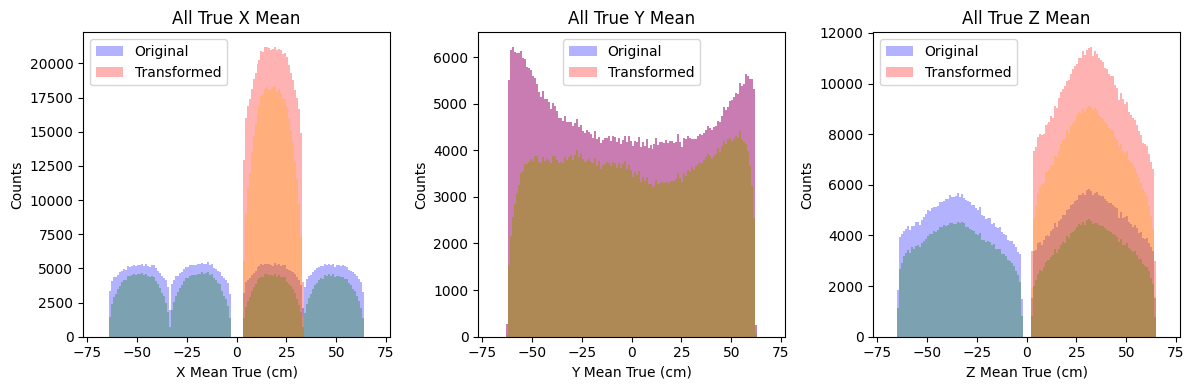

In [19]:
# plot histogram of all true in x y z
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.hist(all_true['x_wmean_int'].dropna(), bins=xbins, color='blue', alpha=0.3)
plt.hist(all_true['x_wmean_int_trfm'].dropna(), bins=xbins, color='red', alpha=0.3)
plt.hist(det_true_rec['x_wmean_int'].dropna(), bins=xbins, color='green', alpha=0.3)
plt.hist(det_true_rec['x_wmean_int_trfm'].dropna(), bins=xbins, color='orange', alpha=0.3)
plt.xlabel('X Mean True (cm)')
plt.ylabel('Counts')
plt.title('All True X Mean')
plt.legend(['Original', 'Transformed'])
plt.subplot(1, 3, 2)
plt.hist(all_true['y_wmean_int'].dropna(), bins=ybins, color='blue', alpha=0.3)
plt.hist(all_true['y_wmean_int_trfm'].dropna(), bins=ybins, color='red', alpha=0.3)
plt.hist(det_true_rec['y_wmean_int'].dropna(), bins=ybins, color='green', alpha=0.3)
plt.hist(det_true_rec['y_wmean_int_trfm'].dropna(), bins=ybins, color='orange', alpha=0.3)
plt.xlabel('Y Mean True (cm)')
plt.ylabel('Counts')
plt.title('All True Y Mean')
plt.legend(['Original', 'Transformed'])
plt.subplot(1, 3, 3)
plt.hist(all_true['z_wmean_int'].dropna(), bins=zbins, color='blue', alpha=0.3)
plt.hist(all_true['z_wmean_int_trfm'].dropna(), bins=zbins, color='red', alpha=0.3)
plt.hist(det_true_rec['z_wmean_int'].dropna(), bins=zbins, color='green', alpha=0.3)
plt.hist(det_true_rec['z_wmean_int_trfm'].dropna(), bins=zbins, color='orange', alpha=0.3)
plt.xlabel('Z Mean True (cm)')
plt.ylabel('Counts')
plt.title('All True Z Mean')
plt.legend(['Original', 'Transformed'])
plt.tight_layout()
plt.show()

In [20]:
# test the 3D slice plotting function
anim_efficiency = plot_3d_efficiency_slices(
    x_A=det_true_reco_x_trfm,
    y_A=det_true_reco_y_trfm,
    z_A=det_true_reco_z_trfm,
    x_B=all_true_x_trfm,
    y_B=all_true_y_trfm,
    z_B=all_true_z_trfm,
    bins_x=xbinst,
    bins_y=ybinst,
    bins_z=zbinst,
    xlabel_list=['X Mean (cm)', 'X Mean (cm)', 'Y Mean (cm)'],
    ylabel_list=['Y Mean (cm)', 'Z Mean (cm)', 'Z Mean (cm)'],
    clabel='Efficiency',
    #neg=True,
    slice_axis='x',
    interval=200,
    bin_mask=bin_mask_3d,
    save_gif='efficiency_xslices.gif',
    fps=2
)

# test the 3D slice plotting function
anim_efficiency = plot_3d_efficiency_slices(
    x_A=det_true_reco_x_trfm,
    y_A=det_true_reco_y_trfm,
    z_A=det_true_reco_z_trfm,
    x_B=all_true_x_trfm,
    y_B=all_true_y_trfm,
    z_B=all_true_z_trfm,
    bins_x=xbinst,
    bins_y=ybinst,
    bins_z=zbinst,
    xlabel_list=['X Mean (cm)', 'X Mean (cm)', 'Y Mean (cm)'],
    ylabel_list=['Y Mean (cm)', 'Z Mean (cm)', 'Z Mean (cm)'],
    clabel='Efficiency',
    #neg=True,
    slice_axis='y',
    interval=200,
    bin_mask=bin_mask_3d,
    save_gif='efficiency_yslices.gif',
    fps=2
)

# test the 3D slice plotting function
anim_efficiency = plot_3d_efficiency_slices(
    x_A=det_true_reco_x_trfm,
    y_A=det_true_reco_y_trfm,
    z_A=det_true_reco_z_trfm,
    x_B=all_true_x_trfm,
    y_B=all_true_y_trfm,
    z_B=all_true_z_trfm,
    bins_x=xbinst,
    bins_y=ybinst,
    bins_z=zbinst,
    xlabel_list=['X Mean (cm)', 'X Mean (cm)', 'Y Mean (cm)'],
    ylabel_list=['Y Mean (cm)', 'Z Mean (cm)', 'Z Mean (cm)'],
    clabel='Efficiency',
    #neg=True,
    slice_axis='z',
    interval=200,
    bin_mask=bin_mask_3d,
    save_gif='efficiency_zslices.gif',
    fps=2
)

/tmp/ipykernel_1899951/1080874041.py:80: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis').copy()


Saved GIF to: efficiency_xslices.gif


/tmp/ipykernel_1899951/1080874041.py:80: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis').copy()


Saved GIF to: efficiency_yslices.gif


/tmp/ipykernel_1899951/1080874041.py:80: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis').copy()


Saved GIF to: efficiency_zslices.gif


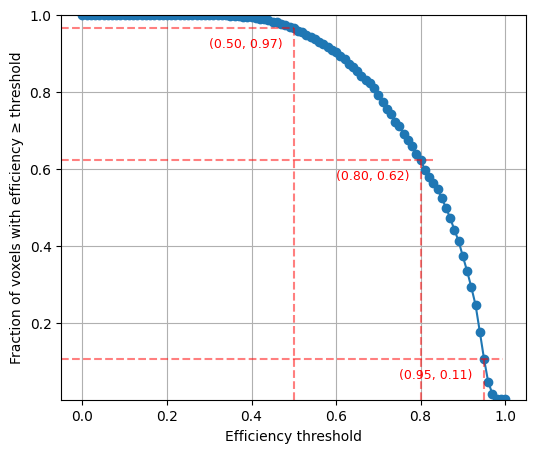

In [21]:
# plot CDF of the fraction of voxels with efficiency > threshold
def plot_efficiency_cdf(
    x_A, y_A, z_A,
    x_B, y_B, z_B,
    bins_x, bins_y, bins_z,
    thresholds=np.linspace(0, 1, 101),
    vlines=None
):
    hist_A, _ = np.histogramdd(
        np.vstack((x_A, y_A, z_A)).T,
        bins=[bins_x, bins_y, bins_z]
    )
    hist_B, _ = np.histogramdd(
        np.vstack((x_B, y_B, z_B)).T,
        bins=[bins_x, bins_y, bins_z]
    )
    eff = np.divide(
        hist_A,
        hist_B,
        out=np.zeros_like(hist_A, dtype=float),
        where=hist_B != 0
    )
    eff_flat = eff.flatten()
    eff_flat = eff_flat[hist_B.flatten() > 0]  # consider only voxels with data

    cdf_values = []
    for thr in thresholds:
        frac = np.sum(eff_flat >= thr) / len(eff_flat)
        cdf_values.append(frac)

    plt.figure(figsize=(6, 5))
    plt.plot(thresholds, cdf_values, marker='o')
    plt.xlabel('Efficiency threshold')
    plt.ylabel('Fraction of voxels with efficiency ≥ threshold')
    for vline in (vlines or []):
      plt.axvline(x=vline, color='r', linestyle='--', alpha=0.5, ymax=(np.interp(vline, thresholds, cdf_values)))
      # Find the y-value at this x threshold
      idx = np.argmin(np.abs(thresholds - vline))
      y_val = cdf_values[idx]
      # Draw horizontal line to the curve
      plt.axhline(y=y_val, color='r', linestyle='--', alpha=0.5, xmax=(vline - thresholds[0]) / (thresholds[-1] - thresholds[0]))
      # Add text labels
      plt.text(vline - 0.2, y_val - 0.05, f'({vline:.2f}, {y_val:.2f})', color='r', fontsize=9)
    plt.grid()
    #plt.yscale('log')
    plt.ylim(1e-4, 1.0)
    plt.show()


det_true_reco_x_trfm_1MeV = det_true_reco_x_trfm[det_true_rec['dE_tot'] >= 1.0]
det_true_reco_y_trfm_1MeV = det_true_reco_y_trfm[det_true_rec['dE_tot'] >= 1.0]
det_true_reco_z_trfm_1MeV = det_true_reco_z_trfm[det_true_rec['dE_tot'] >= 1.0]
all_true_x_trfm_1MeV = all_true_x_trfm[all_true['dE_tot'] >= 1.0]
all_true_y_trfm_1MeV = all_true_y_trfm[all_true['dE_tot'] >= 1.0]
all_true_z_trfm_1MeV = all_true_z_trfm[all_true['dE_tot'] >= 1.0]

plot_efficiency_cdf(
    x_A=det_true_reco_x_trfm_1MeV,
    y_A=det_true_reco_y_trfm_1MeV,
    z_A=det_true_reco_z_trfm_1MeV,
    x_B=all_true_x_trfm_1MeV,
    y_B=all_true_y_trfm_1MeV,
    z_B=all_true_z_trfm_1MeV,
    bins_x=xbinst,
    bins_y=ybinst,
    bins_z=zbinst,
    vlines = [0.5, 0.8, 0.95]
)

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

def plot_efficiency_cdf_multi(
  x_A_list, y_A_list, z_A_list,
  x_B_list, y_B_list, z_B_list,
  bins_x, bins_y, bins_z,
  thresholds=np.linspace(0, 1, 101),
  energy_thresholds=None,
  cmap='viridis',
  log_scale_color=True
):
    """
    Plot CDF of the fraction of voxels with efficiency > threshold for multiple datasets.

    Parameters
    ----------
    x_A_list, y_A_list, z_A_list : list of array-like
      Lists of numerator datasets (successful events)
    x_B_list, y_B_list, z_B_list : list of array-like
      Lists of denominator datasets (all events)
    bins_x, bins_y, bins_z : array-like
      Bin edges for each dimension
    thresholds : array-like
      Efficiency thresholds to evaluate
    energy_thresholds : array-like
      Values to use for coloring (same length as datasets)
    cmap : str
      Matplotlib colormap name
    """

    n_datasets = len(x_A_list)
    if energy_thresholds is None:
        energy_thresholds = np.arange(n_datasets)

    if log_scale_color:
        norm = LogNorm(vmin=np.min(energy_thresholds), vmax=np.max(energy_thresholds))
    else:
        norm = plt.Normalize(vmin=np.min(energy_thresholds), vmax=np.max(energy_thresholds))

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    colors = sm.to_rgba(energy_thresholds)

    plt.figure(figsize=(8, 6))

    for i in range(n_datasets):
        hist_A, _ = np.histogramdd(
            np.vstack((x_A_list[i], y_A_list[i], z_A_list[i])).T,
            bins=[bins_x, bins_y, bins_z]
        )
        hist_B, _ = np.histogramdd(
            np.vstack((x_B_list[i], y_B_list[i], z_B_list[i])).T,
            bins=[bins_x, bins_y, bins_z]
        )
        eff = np.divide(
            hist_A,
            hist_B,
            out=np.zeros_like(hist_A, dtype=float),
            where=hist_B != 0
        )
        eff_flat = eff.flatten()
        eff_flat = eff_flat[hist_B.flatten() > 0]

        cdf_values = []
        for thr in thresholds:
            frac = np.sum(eff_flat >= thr) / len(eff_flat)
            cdf_values.append(frac)

        plt.plot(thresholds, cdf_values, marker='o', color=colors[i], alpha=0.7)

    plt.xlabel('Efficiency threshold')
    plt.ylabel('Fraction of voxels with efficiency ≥ threshold')
    plt.grid(alpha=0.3)
    plt.ylim(0, 1.0)
    plt.tight_layout()

    cbar = plt.colorbar(sm, pad=0.02, ax=plt.gca())
    cbar.set_label('Energy threshold [MeV]')

    plt.show()

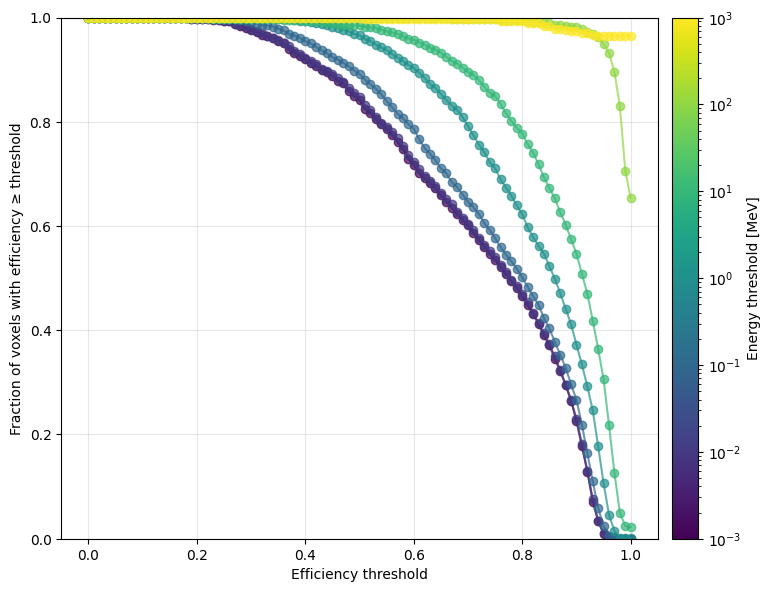

In [23]:
energy_thresholds_MeV = np.logspace(-3, 3, 7)
det_true_reco_x_trfms = []
det_true_reco_y_trfms = []
det_true_reco_z_trfms = []
all_true_x_trfms = []
all_true_y_trfms = []
all_true_z_trfms = []

for ethr in energy_thresholds_MeV:
    det_true_reco_x_trfms.append(
        det_true_reco_x_trfm[det_true_rec['dE_tot'] >= ethr]
    )
    det_true_reco_y_trfms.append(
        det_true_reco_y_trfm[det_true_rec['dE_tot'] >= ethr]
    )
    det_true_reco_z_trfms.append(
        det_true_reco_z_trfm[det_true_rec['dE_tot'] >= ethr]
    )
    all_true_x_trfms.append(
        all_true_x_trfm[all_true['dE_tot'] >= ethr]
    )
    all_true_y_trfms.append(
        all_true_y_trfm[all_true['dE_tot'] >= ethr]
    )
    all_true_z_trfms.append(
        all_true_z_trfm[all_true['dE_tot'] >= ethr]
    )


plot_efficiency_cdf_multi(
    x_A_list=det_true_reco_x_trfms,
    y_A_list=det_true_reco_y_trfms,
    z_A_list=det_true_reco_z_trfms,
    x_B_list=all_true_x_trfms,
    y_B_list=all_true_y_trfms,
    z_B_list=all_true_z_trfms,
    bins_x=xbinst,
    bins_y=ybinst,
    bins_z=zbinst,
    energy_thresholds=energy_thresholds_MeV
)

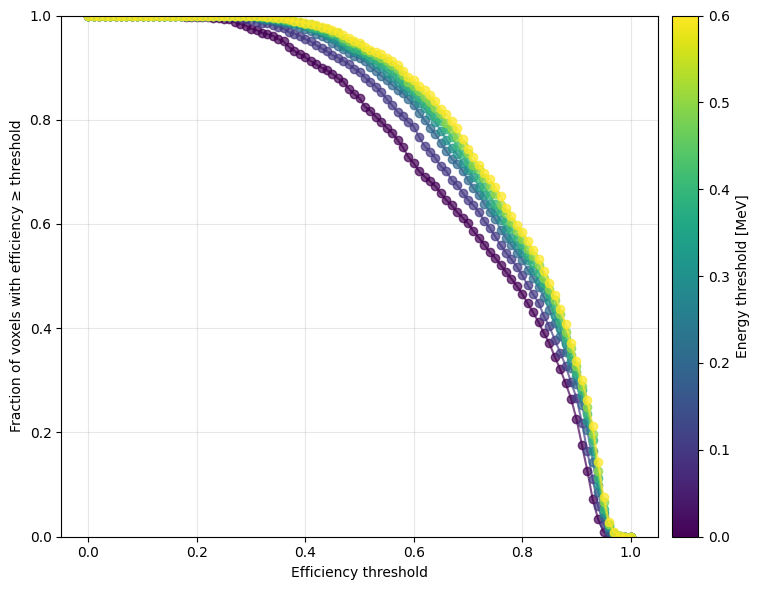

In [24]:
energy_thresholds_MeV = np.linspace(0.0, 0.6, 7)
det_true_reco_x_trfms = []
det_true_reco_y_trfms = []
det_true_reco_z_trfms = []
all_true_x_trfms = []
all_true_y_trfms = []
all_true_z_trfms = []

for ethr in energy_thresholds_MeV:
    det_true_reco_x_trfms.append(
        det_true_reco_x_trfm[det_true_rec['dE_tot'] >= ethr]
    )
    det_true_reco_y_trfms.append(
        det_true_reco_y_trfm[det_true_rec['dE_tot'] >= ethr]
    )
    det_true_reco_z_trfms.append(
        det_true_reco_z_trfm[det_true_rec['dE_tot'] >= ethr]
    )
    all_true_x_trfms.append(
        all_true_x_trfm[all_true['dE_tot'] >= ethr]
    )
    all_true_y_trfms.append(
        all_true_y_trfm[all_true['dE_tot'] >= ethr]
    )
    all_true_z_trfms.append(
        all_true_z_trfm[all_true['dE_tot'] >= ethr]
    )


plot_efficiency_cdf_multi(
    x_A_list=det_true_reco_x_trfms,
    y_A_list=det_true_reco_y_trfms,
    z_A_list=det_true_reco_z_trfms,
    x_B_list=all_true_x_trfms,
    y_B_list=all_true_y_trfms,
    z_B_list=all_true_z_trfms,
    bins_x=xbinst,
    bins_y=ybinst,
    bins_z=zbinst,
    energy_thresholds=energy_thresholds_MeV,
    log_scale_color=False
)

In [30]:
df_use = det_true_rec.copy()
int_to_height = 8.33
threshold_acl = 6 / int_to_height
threshold_lcm = 20 / int_to_height

bin_size_cm = 1.0
xbins = np.arange(-70, 70 + bin_size_cm, bin_size_cm)
ybins = np.arange(-70, 70 + bin_size_cm, bin_size_cm)
zbins = np.arange(-70, 70 + bin_size_cm, bin_size_cm)

# define a dataframe where true interactions have at least 1 detector above threshold
det_to_trap_type = [(i % 4 != 0) for i in range(16)]
print(f"det_to_trap_type: {det_to_trap_type}")

# add column for any det_#_max > 1
det_max_cols = [f'det_{i}_max' for i in range(16)]

# mask for acls
acl_max_cols = [col for col, trap_type in zip(det_max_cols, det_to_trap_type) if not trap_type]
df_truth_reco['any_acl'] = (df_truth_reco[acl_max_cols].max(axis=1) > threshold_acl).astype(int)
print(f"acl_max_cols: {acl_max_cols}")

# mask for lcms
lcms_max_cols = [col for col, trap_type in zip(det_max_cols, det_to_trap_type) if trap_type]
df_truth_reco['any_lcm'] = (df_truth_reco[lcms_max_cols].max(axis=1) > threshold_lcm).astype(int)
print(f"lcms_max_cols: {lcms_max_cols}")

# combinded, for any_det == (any_acl or any_lcm)
df_truth_reco['any_det'] = ((df_truth_reco['any_acl'] == 1) | (df_truth_reco['any_lcm'] == 1)).astype(int)

# print number of events with any_det == 1 (and fraction)
print(f"Number of events with any_det == 1: {df_truth_reco['any_det'].sum()}")
print(f"Fraction of events with any_det == 1: {df_truth_reco['any_det'].mean()}")

if det_max_cols:
    # Check ACLs against threshold_acl
    mask_acl = df_use[acl_max_cols].gt(threshold_acl).any(axis=1).fillna(False)
    # Check LCMs against threshold_lcm
    mask_lcm = df_use[lcms_max_cols].gt(threshold_lcm).any(axis=1).fillna(False)
    # Combine: triggered if either ACL or LCM is above threshold
    mask_triggered = mask_acl | mask_lcm
    df_truth_triggered = df_use[mask_triggered].copy()
    df_truth_untriggered = df_use[~mask_triggered].copy()
else:
    print("Warning: No det_#_max columns found; df_truth_triggered will be empty.")
    df_truth_triggered = df_use.iloc[0:0].copy()
    df_truth_untriggered = df_use.copy()

print(f"Number of triggered events: {len(df_truth_triggered)}")

# define bins in x,y,z position 5 cm x 5 cm x 5 cm
x_bins = np.arange(-75, 80, bin_size_cm)
y_bins = np.arange(-75, 80, bin_size_cm)
z_bins = np.arange(-75, 80, bin_size_cm)

# drop rows with NaNs in positions before binning
pos_cols = ['x_wmean_int_trfm', 'y_wmean_int_trfm', 'z_wmean_int_trfm']
df_pos = df_truth_triggered.dropna(subset=pos_cols)

# get the smallest dE_tot per bin in x,y,z for the triggered events
if df_pos.empty:
    df_triggered_binned = pd.DataFrame(columns=['x_bin', 'y_bin', 'z_bin', 'dE_tot'])
else:
    df_triggered_binned = (
        df_pos
        .groupby([
            pd.cut(df_pos['x_wmean_int_trfm'], bins=x_bins, include_lowest=True),
            pd.cut(df_pos['y_wmean_int_trfm'], bins=y_bins, include_lowest=True),
            pd.cut(df_pos['z_wmean_int_trfm'], bins=z_bins, include_lowest=True),
        ], observed=True)
        .agg({'dE_tot': 'min'})
        .reset_index()
        .rename(columns={'x_wmean_int_trfm': 'x_bin', 'y_wmean_int_trfm': 'y_bin', 'z_wmean_int_trfm': 'z_bin'})
    )

print(df_triggered_binned.head())

# untriggered events
df_untriggered_binned = pd.DataFrame(columns=['x_bin', 'y_bin', 'z_bin', 'dE_tot'])
if not df_truth_untriggered.empty:
    df_untriggered_pos = df_truth_untriggered.dropna(subset=pos_cols)
    if not df_untriggered_pos.empty:
        df_untriggered_binned = (
            df_untriggered_pos
            .groupby([
                pd.cut(df_untriggered_pos['x_wmean_int_trfm'], bins=x_bins, include_lowest=True),
                pd.cut(df_untriggered_pos['y_wmean_int_trfm'], bins=y_bins, include_lowest=True),
                pd.cut(df_untriggered_pos['z_wmean_int_trfm'], bins=z_bins, include_lowest=True),
            ], observed=True)
            .agg({'dE_tot': 'min'})
            .reset_index()
            .rename(columns={'x_wmean_int_trfm': 'x_bin', 'y_wmean_int_trfm': 'y_bin', 'z_wmean_int_trfm': 'z_bin'})
        )

print(df_untriggered_binned.head())

det_to_trap_type: [False, True, True, True, False, True, True, True, False, True, True, True, False, True, True, True]
acl_max_cols: ['det_0_max', 'det_4_max', 'det_8_max', 'det_12_max']
lcms_max_cols: ['det_1_max', 'det_2_max', 'det_3_max', 'det_5_max', 'det_6_max', 'det_7_max', 'det_9_max', 'det_10_max', 'det_11_max', 'det_13_max', 'det_14_max', 'det_15_max']
Number of events with any_det == 1: 693448
Fraction of events with any_det == 1: 0.8428437383013997
Number of triggered events: 452665
        x_bin           y_bin         z_bin     dE_tot
0  (3.0, 4.0]  (-63.0, -62.0]    (4.0, 5.0]  16.632696
1  (3.0, 4.0]  (-63.0, -62.0]  (50.0, 51.0]   1.151025
2  (3.0, 4.0]  (-62.0, -61.0]    (4.0, 5.0]   0.100643
3  (3.0, 4.0]  (-62.0, -61.0]    (5.0, 6.0]   0.118577
4  (3.0, 4.0]  (-62.0, -61.0]    (6.0, 7.0]   0.086824
Empty DataFrame
Columns: [x_bin, y_bin, z_bin, dE_tot]
Index: []


In [31]:
# plot the specified quantile of dE_tot in each (x,y), (x,z), (y,z) bin for chosen events
def plot_dE_tot_heatmaps_div_quantile(
  df_binned,
  quantile=0.5,
  log_scale=False,
  overlay_tpc_bounds=False,
  contour_levels=[1.0],
  contour_kwargs=None
):
  """
  Plot 2D heatmaps of specified quantile of dE_tot in (x,y), (x,z), (y,z) bins for chosen events.
  quantile: float between 0 and 1 specifying which quantile to compute.
  log_scale: if True use log10 color scale (contour_levels interpreted in linear scale then log10'd).
  overlay_tpc_bounds: overlay TPC boundaries as dashed lines.
  contour_levels: list of dE_tot values (linear scale) at which to draw contours (None / empty disables).
  contour_kwargs: optional dict passed to plt.contour (e.g. {'colors':'white','linewidths':1})
  """
  if contour_kwargs is None:
    contour_kwargs = {'colors': 'white', 'linewidths': 1, 'linestyles': 'solid'}

  plt.figure(figsize=(15, 5))

  # (X, Y)
  ax1 = plt.subplot(1, 3, 1)
  x_vals = df_binned['x_bin'].apply(lambda x: x.mid).values
  y_vals = df_binned['y_bin'].apply(lambda y: y.mid).values

  # Compute quantile for each bin
  df_temp = df_binned.copy()
  df_temp['x_idx'] = np.digitize(x_vals, xbins) - 1
  df_temp['y_idx'] = np.digitize(y_vals, ybins) - 1
  H_xy = np.zeros((len(xbins)-1, len(ybins)-1))
  for i in range(len(xbins)-1):
    for j in range(len(ybins)-1):
      mask = (df_temp['x_idx'] == i) & (df_temp['y_idx'] == j)
      if mask.sum() > 0:
        H_xy[i, j] = df_temp.loc[mask, 'dE_tot'].quantile(quantile)
  xedges = xbins
  yedges = ybins

  # (X, Z)
  ax2 = plt.subplot(1, 3, 2)
  z_vals = df_binned['z_bin'].apply(lambda z: z.mid).values
  df_temp['z_idx'] = np.digitize(z_vals, zbins) - 1
  H_xz = np.zeros((len(xbins)-1, len(zbins)-1))
  for i in range(len(xbins)-1):
    for k in range(len(zbins)-1):
      mask = (df_temp['x_idx'] == i) & (df_temp['z_idx'] == k)
      if mask.sum() > 0:
        H_xz[i, k] = df_temp.loc[mask, 'dE_tot'].quantile(quantile)
  xedges2 = xbins
  zedges = zbins
  # (Y, Z)
  ax3 = plt.subplot(1, 3, 3)
  H_zy = np.zeros((len(zbins)-1, len(ybins)-1))
  for k in range(len(zbins)-1):
    for j in range(len(ybins)-1):
      mask = (df_temp['z_idx'] == k) & (df_temp['y_idx'] == j)
      if mask.sum() > 0:
        H_zy[k, j] = df_temp.loc[mask, 'dE_tot'].quantile(quantile)
  zedges2 = zbins
  yedges2 = ybins

  # Prepare data for color scale
  if log_scale:
    data_xy = np.log10(np.where(H_xy > 0, H_xy, np.nan))
    data_xz = np.log10(np.where(H_xz > 0, H_xz, np.nan))
    data_zy = np.log10(np.where(H_zy > 0, H_zy, np.nan))
    cbar_label = 'log10(Quantile dE_tot)'
  else:
    data_xy = H_xy
    data_xz = H_xz
    data_zy = H_zy
    cbar_label = 'Quantile dE_tot'
  # Find symmetric color scale limits
  vmin = np.nanmin([np.nanmin(data_xy), np.nanmin(data_xz), np.nanmin(data_zy)])
  vmax = np.nanmax([np.nanmax(data_xy), np.nanmax(data_xz), np.nanmax(data_zy)])
  abs_max = np.nanmax(np.abs([vmin, vmax]))
  vmin, vmax = -abs_max, abs_max

  # (X, Y)
  im1 = ax1.imshow(
    data_xy.T, origin='lower', extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
    cmap='bwr', aspect='auto', vmin=vmin, vmax=vmax
  )
  plt.colorbar(im1, ax=ax1, label=cbar_label, shrink=1.0)
  if contour_levels:
    levels = [np.log10(l) for l in contour_levels] if log_scale else contour_levels
    X = (xedges[:-1] + xedges[1:]) / 2
    Y = (yedges[:-1] + yedges[1:]) / 2
    Xg, Yg = np.meshgrid(X, Y)
    ax1.contour(Xg, Yg, data_xy.T, levels=levels, **contour_kwargs)
  if overlay_tpc_bounds:
    for bounds in tpc_bounds_cm:
      x_min_cm, x_max_cm = bounds[0][0], bounds[1][0]
      y_min_cm, y_max_cm = bounds[0][1], bounds[1][1]
      ax1.axvline(x=x_min_cm, color='k', linestyle='dashed', linewidth=1)
      ax1.axvline(x=x_max_cm, color='k', linestyle='dashed', linewidth=1)
      ax1.axhline(y=y_min_cm, color='k', linestyle='dashed', linewidth=1)
      ax1.axhline(y=y_max_cm, color='k', linestyle='dashed', linewidth=1)
  ax1.set_xlabel('X Position (cm)')
  ax1.set_ylabel('Y Position (cm)')
  # (X, Z)
  im2 = ax2.imshow(
    data_xz.T, origin='lower', extent=[xedges2[0], xedges2[-1], zedges[0], zedges[-1]],
    cmap='bwr', aspect='auto', vmin=vmin, vmax=vmax
  )
  plt.colorbar(im2, ax=ax2, label=cbar_label, shrink=1.0)
  if contour_levels:
    levels = [np.log10(l) for l in contour_levels] if log_scale else contour_levels
    X = (xedges2[:-1] + xedges2[1:]) / 2
    Z = (zedges[:-1] + zedges[1:]) / 2
    Xg, Zg = np.meshgrid(X, Z)
    ax2.contour(Xg, Zg, data_xz.T, levels=levels, **contour_kwargs)
  if overlay_tpc_bounds:
    for bounds in tpc_bounds_cm:
      x_min_cm, x_max_cm = bounds[0][0], bounds[1][0]
      z_min_cm, z_max_cm = bounds[0][2], bounds[1][2]
      ax2.axvline(x=x_min_cm, color='k', linestyle='dashed', linewidth=1)
      ax2.axvline(x=x_max_cm, color='k', linestyle='dashed', linewidth=1)
      ax2.axhline(y=z_min_cm, color='k', linestyle='dashed', linewidth=1)
      ax2.axhline(y=z_max_cm, color='k', linestyle='dashed', linewidth=1)
  ax2.set_xlabel('X Position (cm)')
  ax2.set_ylabel('Z Position (cm)')
  # (Y, Z)
  im3 = ax3.imshow(
    data_zy.T, origin='lower', extent=[yedges2[0], yedges2[-1], zedges2[0], zedges2[-1]],
    cmap='bwr', aspect='auto', vmin=vmin, vmax=vmax
  )
  plt.colorbar(im3, ax=ax3, label=cbar_label, shrink=1.0)
  if contour_levels:
    levels = [np.log10(l) for l in contour_levels] if log_scale else contour_levels
    Y = (yedges2[:-1] + yedges2[1:]) / 2
    Z = (zedges2[:-1] + zedges2[1:]) / 2
    Zg, Yg = np.meshgrid(Z, Y)
    ax3.contour(Zg, Yg, data_zy.T, levels=levels, **contour_kwargs)
  if overlay_tpc_bounds:
    for bounds in tpc_bounds_cm:
      y_min_cm, y_max_cm = bounds[0][1], bounds[1][1]
      z_min_cm, z_max_cm = bounds[0][2], bounds[1][2]
      ax3.axvline(x=z_min_cm, color='k', linestyle='dashed', linewidth=1)
      ax3.axvline(x=z_max_cm, color='k', linestyle='dashed', linewidth=1)
      ax3.axhline(y=y_min_cm, color='k', linestyle='dashed', linewidth=1)
      ax3.axhline(y=y_max_cm, color='k', linestyle='dashed', linewidth=1)
  ax3.set_xlabel('Z Position (cm)')
  ax3.set_ylabel('Y Position (cm)')
  plt.tight_layout()
  plt.show()

/tmp/ipykernel_1899951/3505355582.py:88: RuntimeWarning: divide by zero encountered in log10
  levels = [np.log10(l) for l in contour_levels] if log_scale else contour_levels
/tmp/ipykernel_1899951/3505355582.py:110: RuntimeWarning: divide by zero encountered in log10
  levels = [np.log10(l) for l in contour_levels] if log_scale else contour_levels
/tmp/ipykernel_1899951/3505355582.py:132: RuntimeWarning: divide by zero encountered in log10
  levels = [np.log10(l) for l in contour_levels] if log_scale else contour_levels


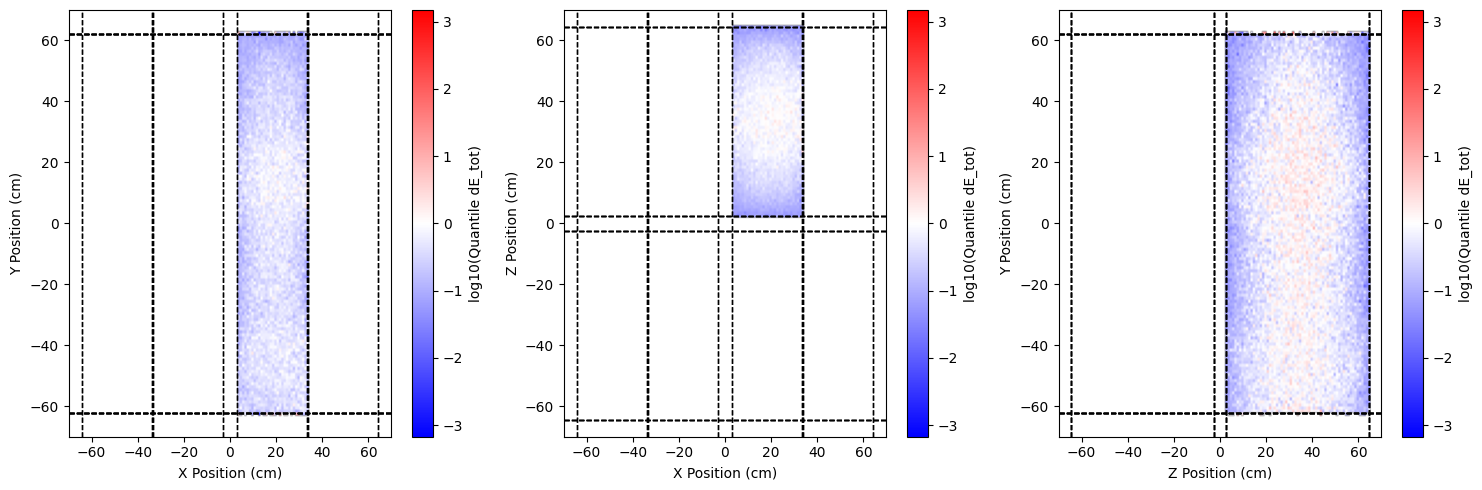

In [32]:
plot_dE_tot_heatmaps_div_quantile(df_triggered_binned,
                     quantile=0.16,
                     log_scale=True,
                     overlay_tpc_bounds=True,
                     contour_levels=[0],
                     contour_kwargs={'colors':'black',
                                     'linewidths':1})

/tmp/ipykernel_1899951/3505355582.py:76: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin([np.nanmin(data_xy), np.nanmin(data_xz), np.nanmin(data_zy)])
/tmp/ipykernel_1899951/3505355582.py:76: RuntimeWarning: All-NaN axis encountered
  vmin = np.nanmin([np.nanmin(data_xy), np.nanmin(data_xz), np.nanmin(data_zy)])
/tmp/ipykernel_1899951/3505355582.py:77: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax([np.nanmax(data_xy), np.nanmax(data_xz), np.nanmax(data_zy)])
/tmp/ipykernel_1899951/3505355582.py:77: RuntimeWarning: All-NaN axis encountered
  vmax = np.nanmax([np.nanmax(data_xy), np.nanmax(data_xz), np.nanmax(data_zy)])
/tmp/ipykernel_1899951/3505355582.py:78: RuntimeWarning: All-NaN slice encountered
  abs_max = np.nanmax(np.abs([vmin, vmax]))
/tmp/ipykernel_1899951/3505355582.py:88: RuntimeWarning: divide by zero encountered in log10
  levels = [np.log10(l) for l in contour_levels] if log_scale else contour_levels
/tmp/ipykernel_1899951/3505355582.py:110: Ru

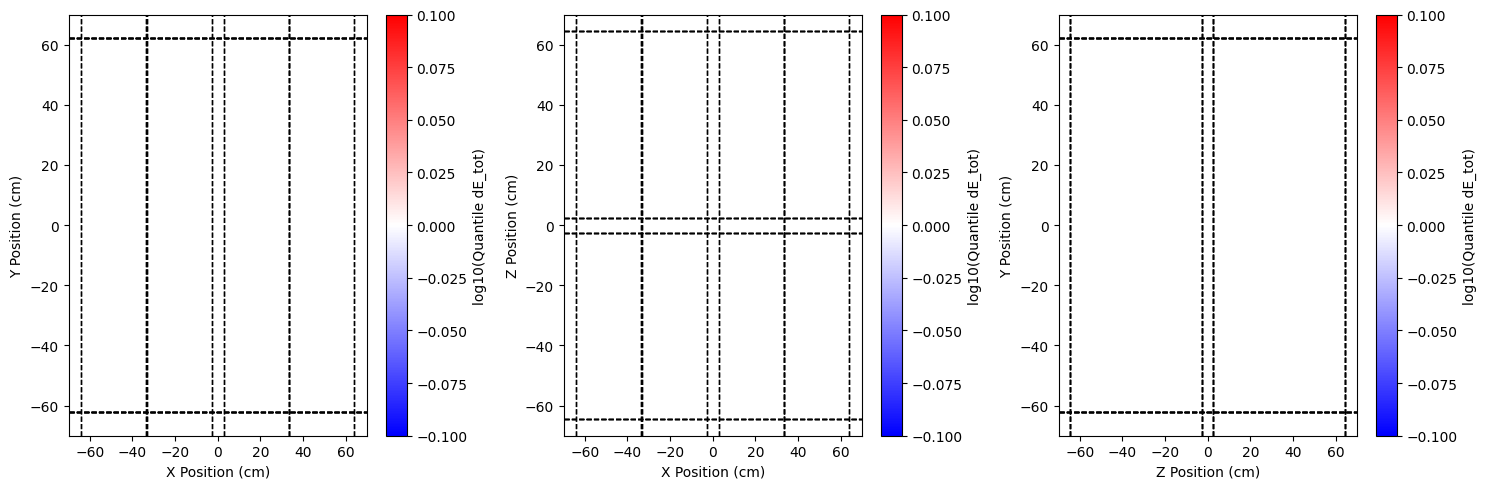

In [33]:

plot_dE_tot_heatmaps_div_quantile(df_untriggered_binned,
                     quantile=0.84,
                     log_scale=True,
                     overlay_tpc_bounds=True,
                     contour_levels=[0],
                     contour_kwargs={'colors':'black',
                                     'linewidths':1})